In [1]:
import requests
import time

# Streams Bitcoin OHLC candle data from CoinGecko API.
# Each batch contains a fixed number of candle records.
def stream_bitcoin_ohlc(batch_size=5, pause=1.0):

    url = "https://api.coingecko.com/api/v3/coins/bitcoin/ohlc?vs_currency=usd&days=1"

    while True:
        batch = []

        try:
            # Request OHLC data
            r = requests.get(url, timeout=5)
            data = r.json()

            # Extract first N candles
            for candle in data[:batch_size]:

                record = {
                    "timestamp": candle[0],
                    "open": candle[1],
                    "high": candle[2],
                    "low": candle[3],
                    "close": candle[4]
                }

                batch.append(record)

        except Exception as e:
            batch.append({"error": str(e)})

        yield batch
        time.sleep(pause)

# Create stream
btc_stream = stream_bitcoin_ohlc(
    batch_size=5,
    pause=1.0
)

# Get first batch
initial_batch = next(btc_stream)

print("Initial streamed BTC OHLC candles:")

for candle in initial_batch:
    print(candle)

Initial streamed BTC OHLC candles:
{'timestamp': 1778490000000, 'open': 80656.0, 'high': 80814.0, 'low': 80656.0, 'close': 80741.0}
{'timestamp': 1778491800000, 'open': 80772.0, 'high': 80917.0, 'low': 80772.0, 'close': 80908.0}
{'timestamp': 1778493600000, 'open': 80874.0, 'high': 80942.0, 'low': 80865.0, 'close': 80930.0}
{'timestamp': 1778495400000, 'open': 80942.0, 'high': 81154.0, 'low': 80942.0, 'close': 81154.0}
{'timestamp': 1778497200000, 'open': 81134.0, 'high': 81134.0, 'low': 80943.0, 'close': 80943.0}


In [3]:
import dask.dataframe as dd
import pandas as pd

# Define consistent dtypes for Bitcoin OHLC data.
dtypes = {
    "timestamp": "int64",
    "open": "float64",
    "high": "float64",
    "low": "float64",
    "close": "float64"
}

# Start with an empty pandas DataFrame using fixed dtypes.
pdf = pd.DataFrame({
    col: pd.Series(dtype=dt)
    for col, dt in dtypes.items()
})

# Convert to Dask DataFrame once.
ddf = dd.from_pandas(pdf, npartitions=1)

# Ingest one streamed batch.
batch = next(btc_stream)

# Convert batch into pandas DataFrame.
batch_df = pd.DataFrame(batch).astype(dtypes)

# Append using Dask concat.
ddf = dd.concat(
    [ddf, dd.from_pandas(batch_df, npartitions=1)],
    axis=0,
    interleave_partitions=True
)

# Reset index so Dask knows the first partition has rows.
ddf = ddf.reset_index(drop=True)

# Repartition to ensure head() works without warnings.
ddf = ddf.repartition(npartitions=1)

# Show dataset size.
print("Rows collected so far:", ddf.shape[0].compute())

# Preview structure without warnings.
print(ddf.head())

Rows collected so far: 5
       timestamp     open     high      low    close
0  1778490000000  80656.0  80814.0  80656.0  80741.0
1  1778491800000  80772.0  80917.0  80772.0  80908.0
2  1778493600000  80874.0  80942.0  80865.0  80930.0
3  1778495400000  80942.0  81154.0  80942.0  81154.0
4  1778497200000  81134.0  81134.0  80943.0  80943.0


In [7]:
# Live streaming loop for Bitcoin OHLC data

import pandas as pd
import dask.dataframe as dd
import time

# Number of batches
num_batches = 10

for i in range(num_batches):

    # Fetch next batch
    batch = next(btc_stream)

    # Skip batch if API returned error
    if "error" in batch[0]:
        print(f"\nBatch {i+1} failed:")
        print(batch[0]["error"])
        continue

    # Convert batch into DataFrame
    batch_df = pd.DataFrame(batch)

    # Apply dtypes safely
    batch_df = batch_df.astype(dtypes)

    # Display batch
    print(f"\nBatch {i+1} received:")
    print(batch_df)

    # Append into Dask DataFrame
    ddf = dd.concat(
        [ddf, dd.from_pandas(batch_df, npartitions=1)],
        axis=0,
        interleave_partitions=True
    )

    # Clean metadata
    ddf = ddf.reset_index(drop=True)
    ddf = ddf.repartition(npartitions=1)

    # Pause between batches
    time.sleep(1)

print("\nStreaming complete.")
print("Total rows collected:", ddf.shape[0].compute())


Batch 1 received:
       timestamp     open     high      low    close
0  1778490000000  80656.0  80814.0  80656.0  80741.0
1  1778491800000  80772.0  80917.0  80772.0  80908.0
2  1778493600000  80874.0  80942.0  80865.0  80930.0
3  1778495400000  80942.0  81154.0  80942.0  81154.0
4  1778497200000  81134.0  81134.0  80943.0  80943.0

Batch 2 received:
       timestamp     open     high      low    close
0  1778490000000  80656.0  80814.0  80656.0  80741.0
1  1778491800000  80772.0  80917.0  80772.0  80908.0
2  1778493600000  80874.0  80942.0  80865.0  80930.0
3  1778495400000  80942.0  81154.0  80942.0  81154.0
4  1778497200000  81134.0  81134.0  80943.0  80943.0

Batch 3 received:
       timestamp     open     high      low    close
0  1778490000000  80656.0  80814.0  80656.0  80741.0
1  1778491800000  80772.0  80917.0  80772.0  80908.0
2  1778493600000  80874.0  80942.0  80865.0  80930.0
3  1778495400000  80942.0  81154.0  80942.0  81154.0
4  1778497200000  81134.0  81134.0  80943.

Matplotlib is building the font cache; this may take a moment.


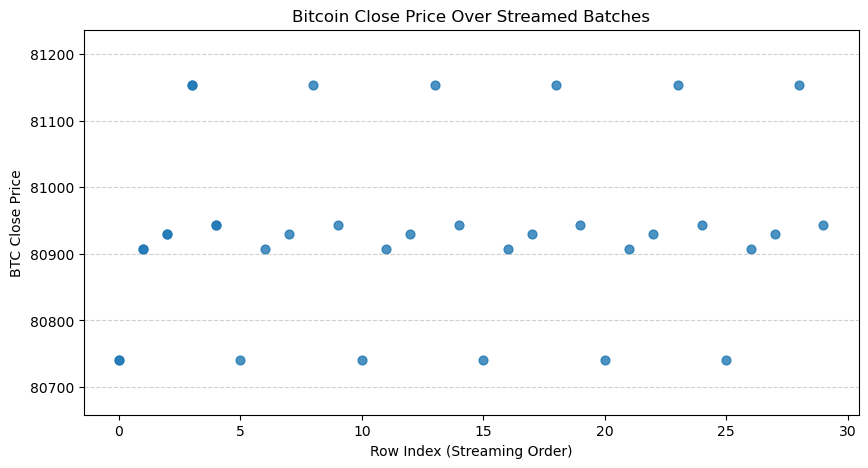

In [9]:
import matplotlib.pyplot as plt

# Convert Dask DataFrame to pandas for plotting
pdf_plot = ddf.compute()

# Drop missing values (just in case)
pdf_plot = pdf_plot.dropna(subset=["close"])

# Scatter plot: Close price over streaming order (row index)
plt.figure(figsize=(10, 5))

plt.scatter(
    pdf_plot.index,
    pdf_plot["close"],
    color="tab:blue",
    alpha=0.8,
    s=40
)

plt.xlabel("Row Index (Streaming Order)")
plt.ylabel("BTC Close Price")
plt.title("Bitcoin Close Price Over Streamed Batches")
plt.grid(axis="y", linestyle="--", alpha=0.6)

# Improve spacing
plt.margins(x=0.05, y=0.2)

plt.show()

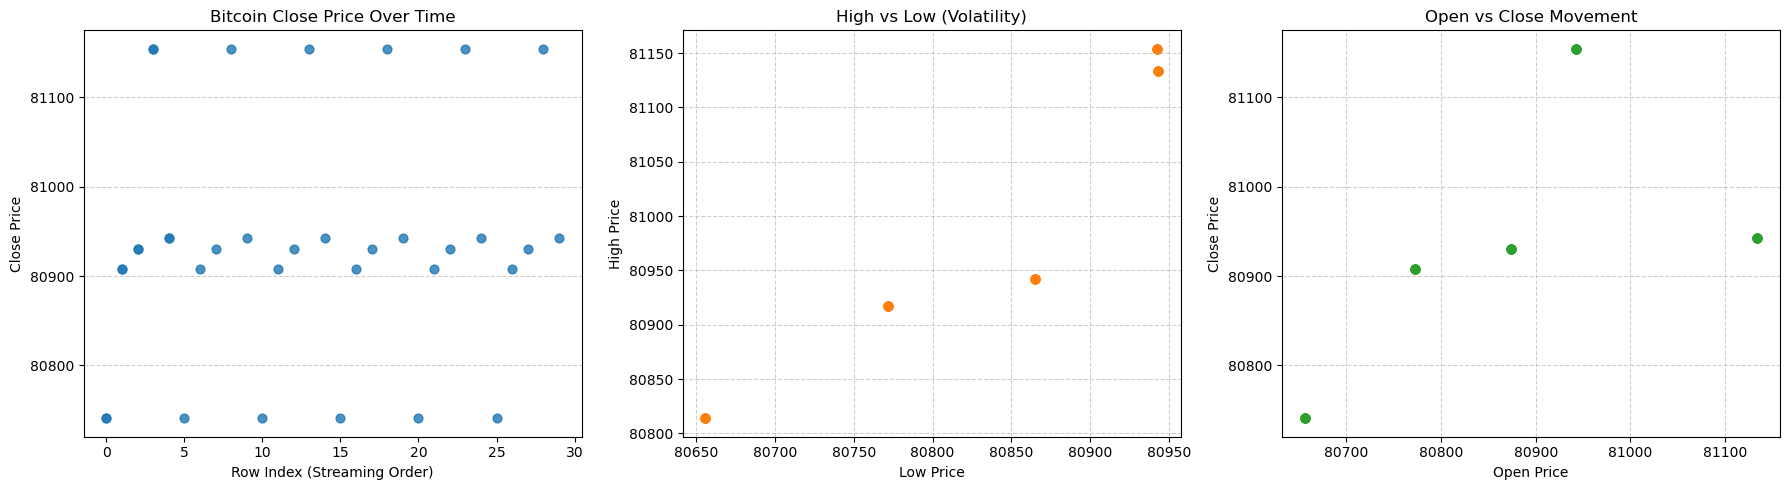

In [11]:
import matplotlib.pyplot as plt

# Convert Dask DataFrame to pandas
pdf_plot = ddf.compute()

# Drop missing values
pdf_plot = pdf_plot.dropna(subset=["open", "high", "low", "close"])

# Create 1x3 dashboard
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Panel 1: Close price over time (stream order) ---
axes[0].scatter(
    pdf_plot.index,
    pdf_plot["close"],
    color="tab:blue",
    alpha=0.8,
    s=40
)
axes[0].set_xlabel("Row Index (Streaming Order)")
axes[0].set_ylabel("Close Price")
axes[0].grid(axis="y", linestyle="--", alpha=0.6)
axes[0].set_title("Bitcoin Close Price Over Time")

# --- Panel 2: Volatility (High vs Low) ---
axes[1].scatter(
    pdf_plot["low"],
    pdf_plot["high"],
    color="tab:orange",
    alpha=0.7,
    s=40
)
axes[1].set_xlabel("Low Price")
axes[1].set_ylabel("High Price")
axes[1].grid(axis="both", linestyle="--", alpha=0.6)
axes[1].set_title("High vs Low (Volatility)")

# --- Panel 3: Price movement structure (Open vs Close) ---
axes[2].scatter(
    pdf_plot["open"],
    pdf_plot["close"],
    color="tab:green",
    alpha=0.7,
    s=40
)
axes[2].set_xlabel("Open Price")
axes[2].set_ylabel("Close Price")
axes[2].grid(axis="both", linestyle="--", alpha=0.6)
axes[2].set_title("Open vs Close Movement")

plt.tight_layout()
plt.show()

In [13]:
print("Total rows:", len(pdf_plot))

print("Rows with open:", pdf_plot["open"].notna().sum())
print("Rows with high:", pdf_plot["high"].notna().sum())
print("Rows with low:", pdf_plot["low"].notna().sum())
print("Rows with close:", pdf_plot["close"].notna().sum())
print("Rows with timestamp:", pdf_plot["timestamp"].notna().sum())

Total rows: 35
Rows with open: 35
Rows with high: 35
Rows with low: 35
Rows with close: 35
Rows with timestamp: 35


In [15]:
pdf_plot[["open", "high", "low", "close"]].value_counts().head(10)

open     high     low      close  
80656.0  80814.0  80656.0  80741.0    7
80772.0  80917.0  80772.0  80908.0    7
80874.0  80942.0  80865.0  80930.0    7
80942.0  81154.0  80942.0  81154.0    7
81134.0  81134.0  80943.0  80943.0    7
Name: count, dtype: int64

In [17]:
(pdf_plot["high"] - pdf_plot["low"]).value_counts().head(10)

158.0    7
145.0    7
77.0     7
212.0    7
191.0    7
Name: count, dtype: int64

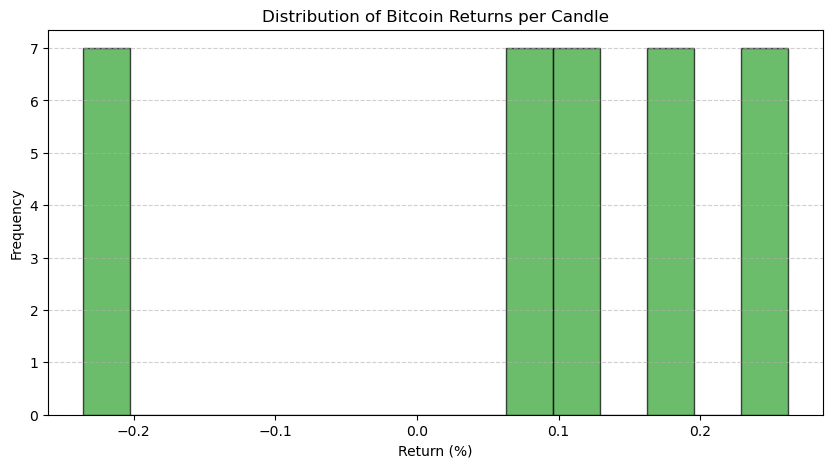

In [23]:
returns = (pdf_plot["close"] - pdf_plot["open"]) / pdf_plot["open"] * 100

plt.figure(figsize=(10, 5))

plt.hist(
    returns,
    bins=15,
    color="tab:green",
    alpha=0.7,
    edgecolor="black"
)

plt.xlabel("Return (%)")
plt.ylabel("Frequency")
plt.title("Distribution of Bitcoin Returns per Candle")
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.show()

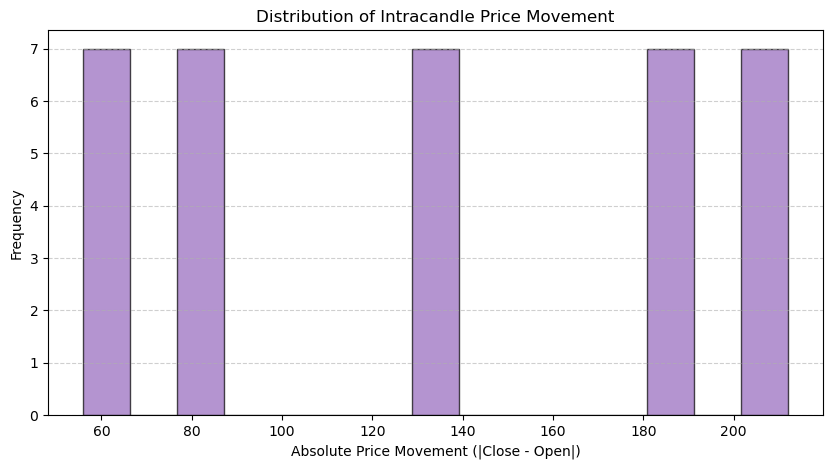

In [37]:
movement = (pdf_plot["close"] - pdf_plot["open"]).abs()

plt.figure(figsize=(10, 5))

plt.hist(
    movement,
    bins=15,
    color="tab:purple",
    alpha=0.7,
    edgecolor="black"
)

plt.xlabel("Absolute Price Movement (|Close - Open|)")
plt.ylabel("Frequency")
plt.title("Distribution of Intracandle Price Movement")
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.show()

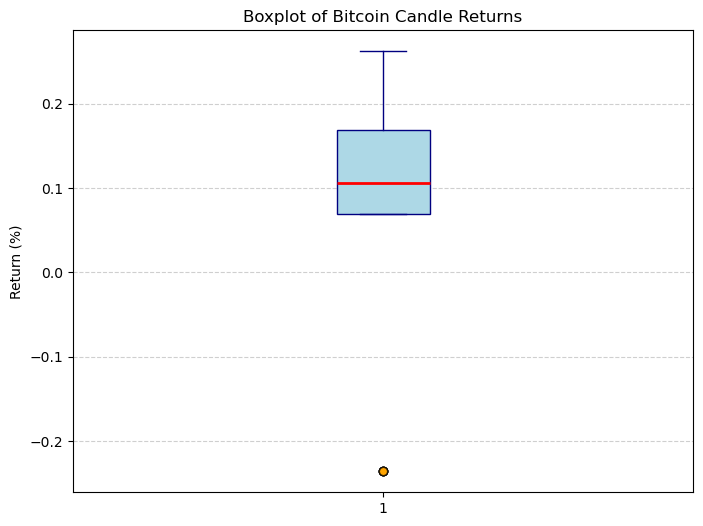

In [39]:
import matplotlib.pyplot as plt

# Convert Dask DataFrame to pandas
pdf_plot = ddf.compute()

# Drop missing values
pdf_plot = pdf_plot.dropna(subset=["open", "close"])

# Compute returns (% change per candle)
returns = (pdf_plot["close"] - pdf_plot["open"]) / pdf_plot["open"] * 100

plt.figure(figsize=(8, 6))

plt.boxplot(
    returns,
    vert=True,
    patch_artist=True,
    boxprops=dict(facecolor="lightblue", color="navy"),
    medianprops=dict(color="red", linewidth=2),
    whiskerprops=dict(color="navy"),
    capprops=dict(color="navy"),
    flierprops=dict(marker="o", markersize=6, markerfacecolor="orange", alpha=0.6)
)

plt.ylabel("Return (%)")
plt.title("Boxplot of Bitcoin Candle Returns")
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.show()

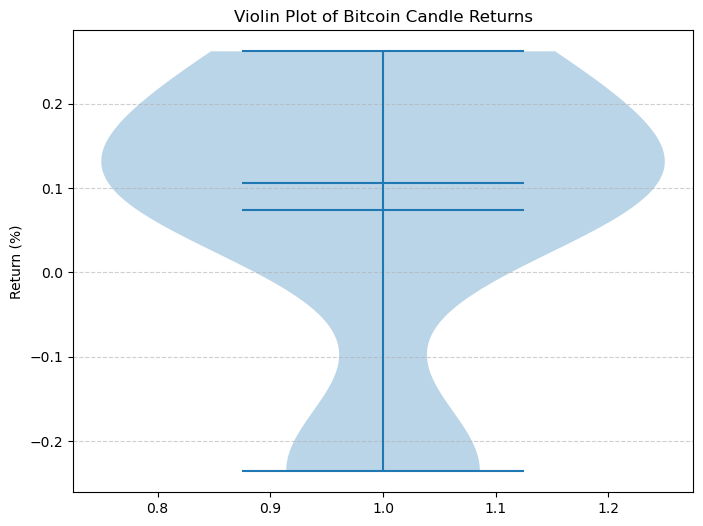

In [41]:
import matplotlib.pyplot as plt

# Convert Dask DataFrame to pandas
pdf_plot = ddf.compute()

# Ensure required columns exist
pdf_plot = pdf_plot.dropna(subset=["open", "close"])

# Compute returns (% change per candle)
returns = (pdf_plot["close"] - pdf_plot["open"]) / pdf_plot["open"] * 100

plt.figure(figsize=(8, 6))

plt.violinplot(
    returns,
    showmeans=True,
    showmedians=True,
    showextrema=True
)

plt.ylabel("Return (%)")
plt.title("Violin Plot of Bitcoin Candle Returns")
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.show()

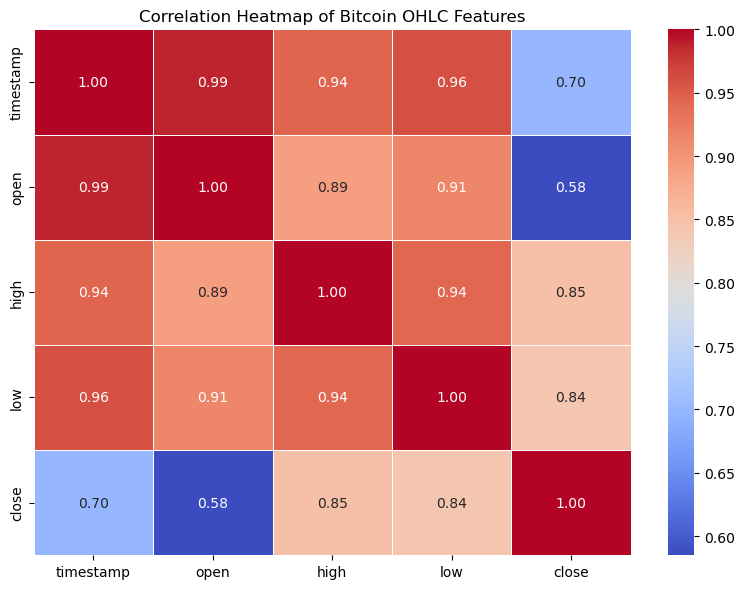

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

# Convert Dask DataFrame to pandas
pdf_plot = ddf.compute()

# Select numeric columns
numeric_df = pdf_plot.select_dtypes(include=["number"])

# Compute correlation matrix
corr = numeric_df.corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5,
    fmt=".2f"
)

plt.title("Correlation Heatmap of Bitcoin OHLC Features")
plt.tight_layout()

plt.show()

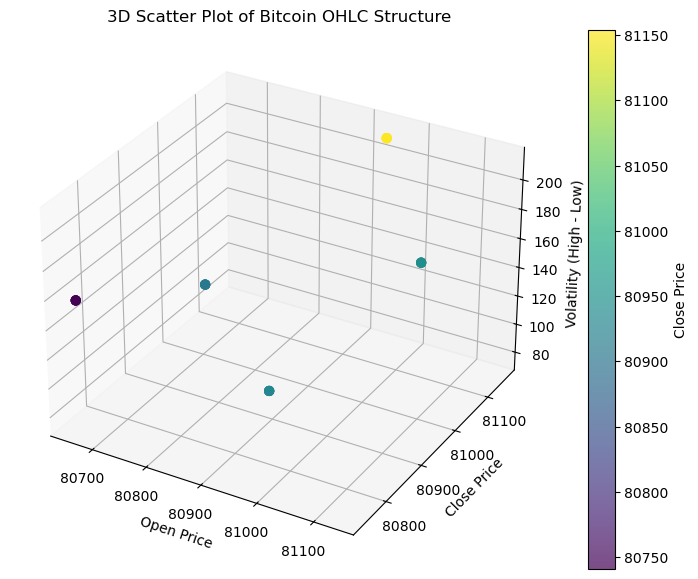

In [45]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Convert Dask DataFrame to pandas
pdf_plot = ddf.compute()

# Drop missing values
pdf_plot = pdf_plot.dropna(subset=["open", "high", "low", "close"])

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(
    pdf_plot["open"],
    pdf_plot["close"],
    pdf_plot["high"] - pdf_plot["low"],  # volatility as 3rd dimension
    c=pdf_plot["close"],
    cmap="viridis",
    s=40,
    alpha=0.7
)

ax.set_xlabel("Open Price")
ax.set_ylabel("Close Price")
ax.set_zlabel("Volatility (High - Low)")
ax.set_title("3D Scatter Plot of Bitcoin OHLC Structure")

cb = plt.colorbar(sc)
cb.set_label("Close Price")

plt.show()

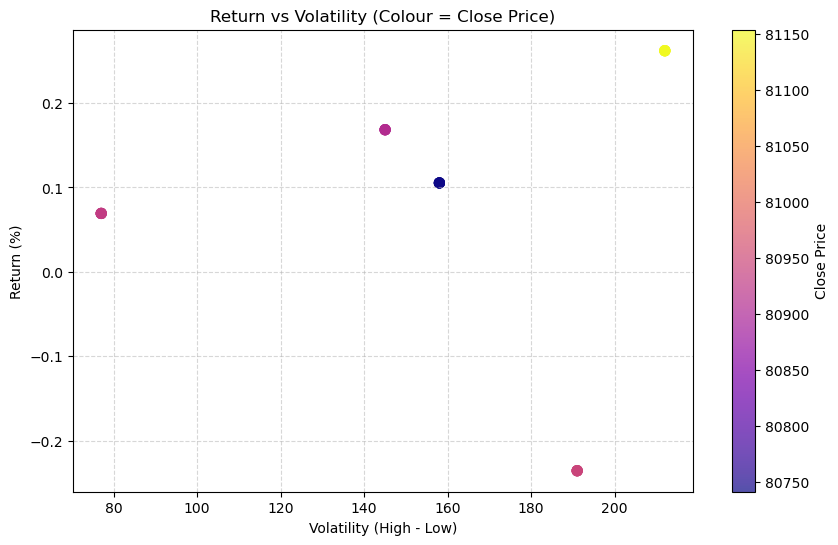

In [47]:
import matplotlib.pyplot as plt

# Convert Dask DataFrame to pandas
pdf_plot = ddf.compute()

# Drop missing values
pdf_plot = pdf_plot.dropna(subset=["open", "high", "low", "close"])

# Compute features
volatility = pdf_plot["high"] - pdf_plot["low"]
returns = (pdf_plot["close"] - pdf_plot["open"]) / pdf_plot["open"] * 100

plt.figure(figsize=(10, 6))

sc = plt.scatter(
    volatility,
    returns,
    c=pdf_plot["close"],   # color = market level
    cmap="plasma",
    s=50,
    alpha=0.7
)

plt.xlabel("Volatility (High - Low)")
plt.ylabel("Return (%)")
plt.title("Return vs Volatility (Colour = Close Price)")

cb = plt.colorbar(sc)
cb.set_label("Close Price")

plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

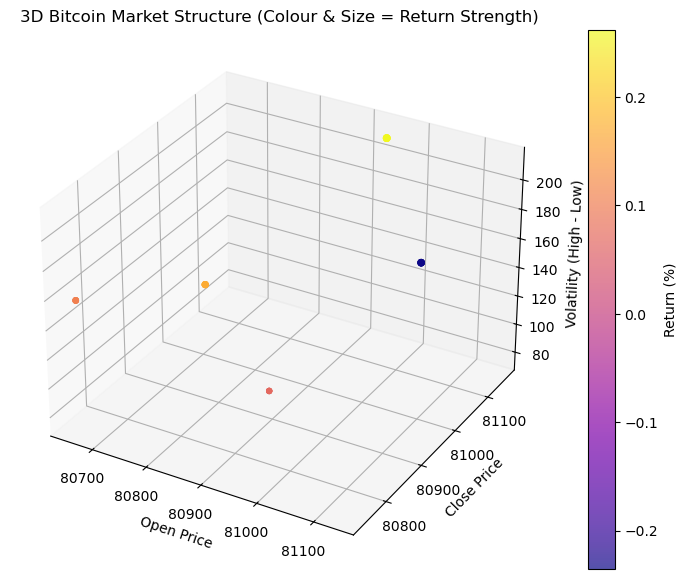

In [51]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Convert Dask DataFrame to pandas
pdf_plot = ddf.compute()

# Clean data
pdf_plot = pdf_plot.dropna(subset=["open", "high", "low", "close"])

# Feature engineering
volatility = pdf_plot["high"] - pdf_plot["low"]
returns = (pdf_plot["close"] - pdf_plot["open"]) / pdf_plot["open"] * 100

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(
    pdf_plot["open"],        # X-axis (like longitude)
    pdf_plot["close"],       # Y-axis (like latitude)
    volatility,              # Z-axis (like depth)
    c=returns,               # colour = magnitude equivalent
    s=abs(returns) * 40 + 10,# bubble size = strength of move
    cmap="plasma",
    alpha=0.7
)

ax.set_xlabel("Open Price")
ax.set_ylabel("Close Price")
ax.set_zlabel("Volatility (High - Low)")
ax.set_title("3D Bitcoin Market Structure (Colour & Size = Return Strength)")

cb = plt.colorbar(sc)
cb.set_label("Return (%)")

plt.show()

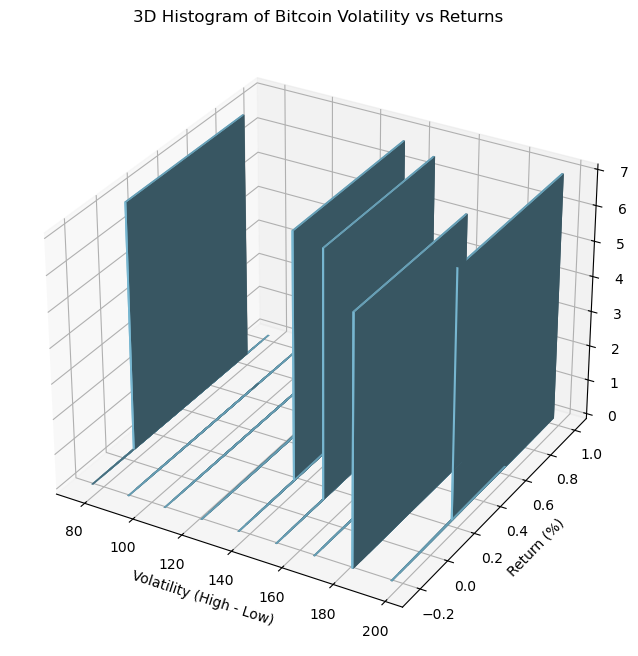

In [53]:
import numpy as np
import matplotlib.pyplot as plt

# Convert Dask DataFrame to pandas
pdf_plot = ddf.compute()

# Clean data
pdf_plot = pdf_plot.dropna(subset=["open", "high", "low", "close"])

# Feature engineering
volatility = pdf_plot["high"] - pdf_plot["low"]
returns = (pdf_plot["close"] - pdf_plot["open"]) / pdf_plot["open"] * 100

# Bin ranges
vol_bins = np.linspace(volatility.min(), volatility.max(), 10)
ret_bins = np.linspace(returns.min(), returns.max(), 10)

# 2D histogram
hist, xedges, yedges = np.histogram2d(
    volatility,
    returns,
    bins=[vol_bins, ret_bins]
)

# Prepare bars
xpos, ypos = np.meshgrid(xedges[:-1], yedges[:-1], indexing="ij")
xpos = xpos.ravel()
ypos = ypos.ravel()
zpos = np.zeros_like(xpos)

dx = dy = 0.8
dz = hist.ravel()

# Plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

ax.bar3d(
    xpos, ypos, zpos,
    dx, dy, dz,
    shade=True,
    color="skyblue"
)

ax.set_xlabel("Volatility (High - Low)")
ax.set_ylabel("Return (%)")
ax.set_zlabel("Frequency")
ax.set_title("3D Histogram of Bitcoin Volatility vs Returns")

plt.show()